로드 & 기본 확인

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    classification_report, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, IsolationForest

import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("creditcard.csv")
print(df.shape)
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True))

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


EDA (루브릭 1번: 시각화로 분포 파악 ✅)

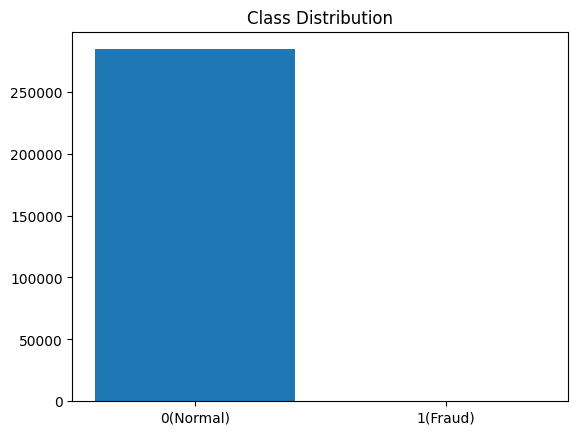

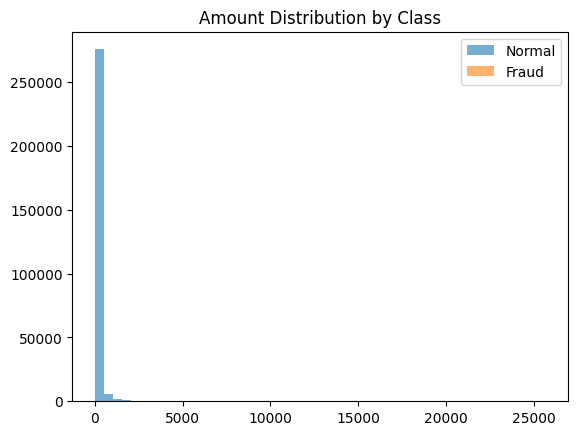

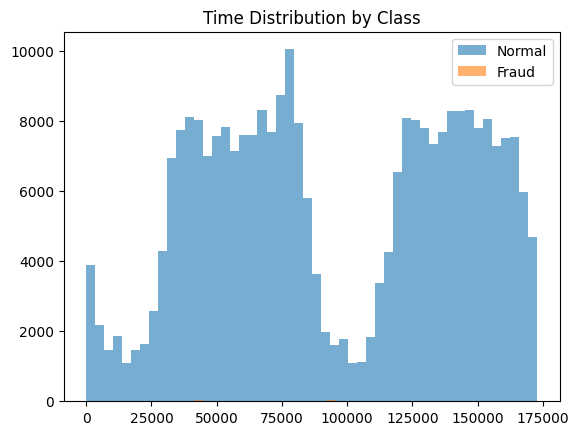

In [16]:
# Class 분포
counts = df['Class'].value_counts().sort_index()
plt.figure()
plt.bar(['0(Normal)', '1(Fraud)'], counts.values)
plt.title('Class Distribution')
plt.show()

# Amount 분포 비교
plt.figure()
plt.hist(df.loc[df['Class']==0,'Amount'], bins=50, alpha=0.6, label='Normal')
plt.hist(df.loc[df['Class']==1,'Amount'], bins=50, alpha=0.6, label='Fraud')
plt.title('Amount Distribution by Class')
plt.legend()
plt.show()

# Time 분포 비교
plt.figure()
plt.hist(df.loc[df['Class']==0,'Time'], bins=50, alpha=0.6, label='Normal')
plt.hist(df.loc[df['Class']==1,'Time'], bins=50, alpha=0.6, label='Fraud')
plt.title('Time Distribution by Class')
plt.legend()
plt.show()

Feature Engineering (누수 없는 구조로 설계)

시간/금액/상호작용은 “단순 변환”이라 전체에 만들어도 OK

IsolationForest 점수는 fold 내부에서 fit/transform (누수 방지)

In [17]:
def base_feature_engineering(data: pd.DataFrame) -> pd.DataFrame:
    d = data.copy()

    # Time 파생
    d['hour'] = (d['Time'] // 3600) % 24
    d['hour_sin'] = np.sin(2 * np.pi * d['hour'] / 24)
    d['hour_cos'] = np.cos(2 * np.pi * d['hour'] / 24)

    # Amount 파생
    d['Amount_log'] = np.log1p(d['Amount'])

    # 핵심 상호작용 변수
    d['V17_V14'] = d['V17'] * d['V14']
    d['V12_V10'] = d['V12'] * d['V10']

    # Amount 스케일링
    scaler = RobustScaler()
    d['Amount_scaled'] = scaler.fit_transform(d[['Amount']])

    # 불필요 원본 컬럼 제거
    d = d.drop(['Time', 'Amount', 'hour'], axis=1)

    return d


df_fe = base_feature_engineering(df)

X = df_fe.drop('Class', axis=1)
y = df_fe['Class']

Train/Test split (최종 평가용 hold-out) ✅

루브릭은 “비교/튜닝”이 핵심이라 CV로 해도 되지만, 마지막에 테스트 성능 한 번 찍어주면 보고서가 탄탄해집니다.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train fraud ratio:", y_train.mean())
print("Test fraud ratio :", y_test.mean())

Train fraud ratio: 0.001729245759178389
Test fraud ratio : 0.0017204452090867595


(핵심) OOF + 누수 없는 anomaly_score + 임계값(F1) 자동 탐색 ✅

여기서 모델은 XGBoost를 기준 모델로 두고,

fold 안에서 IsolationForest를 train에만 fit

valid에는 decision_function(연속 점수)만 주입

OOF 확률로 threshold(F1) 찾기

In [19]:
def add_iforest_score_fold(X_tr, X_va, random_state=42):
    v_cols = [c for c in X_tr.columns if c.startswith('V')]
    iso = IsolationForest(contamination=0.002, random_state=random_state, n_jobs=-1)

    iso.fit(X_tr[v_cols])

    X_tr2 = X_tr.copy()
    X_va2 = X_va.copy()

    # 연속 점수(결정함수) 추가
    X_tr2['anomaly_score'] = iso.decision_function(X_tr[v_cols])
    X_va2['anomaly_score'] = iso.decision_function(X_va[v_cols])

    return X_tr2, X_va2


folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(X_train))

ratio = (y_train == 0).sum() / (y_train == 1).sum()

for fold, (tr_idx, va_idx) in enumerate(folds.split(X_train, y_train), 1):
    X_tr, y_tr = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    X_va, y_va = X_train.iloc[va_idx], y_train.iloc[va_idx]

    X_tr2, X_va2 = add_iforest_score_fold(X_tr, X_va, random_state=42 + fold)

    model = xgb.XGBClassifier(
        n_estimators=2000,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=ratio,
        tree_method="hist",
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_tr2, y_tr, eval_set=[(X_va2, y_va)], verbose=0)

    oof[va_idx] = model.predict_proba(X_va2)[:, 1]
    print(f"Fold {fold} done")

# OOF 성능
oof_roc = roc_auc_score(y_train, oof)
oof_ap = average_precision_score(y_train, oof)
print(f"\n[OOF] ROC-AUC: {oof_roc:.4f} | PR-AUC(AP): {oof_ap:.4f}")

# F1 최적 threshold 탐색(OOF)
precision, recall, thresholds = precision_recall_curve(y_train, oof)
f1 = (2 * precision * recall) / (precision + recall + 1e-12)

# thresholds 길이가 precision/recall보다 1 짧음 → 정렬 맞추기
best_ix = np.argmax(f1[1:])  # 1부터 쓰는 게 보통 안정적
best_thresh = thresholds[best_ix]
best_f1 = f1[best_ix + 1]

print(f"Best threshold (OOF-F1): {best_thresh:.4f} | Best F1: {best_f1:.4f}")

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done

[OOF] ROC-AUC: 0.9827 | PR-AUC(AP): 0.8534
Best threshold (OOF-F1): 0.8228 | Best F1: 0.8634


3개 이상 모델 학습/비교 ✅ (루브릭 2번)

이제 hold-out 테스트에서 모델 3개를 비교합니다.
(불균형 처리도 포함: class_weight, scale_pos_weight)

In [20]:
# train 전체로 iforest fit → train/test에 anomaly_score 추가
def add_iforest_score_full(X_tr, X_te, random_state=42):
    v_cols = [c for c in X_tr.columns if c.startswith('V')]
    iso = IsolationForest(contamination=0.002, random_state=random_state, n_jobs=-1)

    iso.fit(X_tr[v_cols])

    X_tr2 = X_tr.copy()
    X_te2 = X_te.copy()

    X_tr2["anomaly_score"] = iso.decision_function(X_tr[v_cols])
    X_te2["anomaly_score"] = iso.decision_function(X_te[v_cols])

    return X_tr2, X_te2


X_train2, X_test2 = add_iforest_score_full(X_train, X_test)

# (보험) 컬럼 순서 고정: fit/predict 컬럼 mismatch 방지
X_test2 = X_test2.reindex(columns=X_train2.columns)


def evaluate_prob(name, y_true, prob):
    roc = roc_auc_score(y_true, prob)
    ap = average_precision_score(y_true, prob)
    pred = (prob >= best_thresh).astype(int)
    print(f"{name:>18} | ROC-AUC {roc:.4f} | PR-AUC {ap:.4f} | PredFraud {pred.sum()}")
    return roc, ap, pred


# 1) Logistic Regression
lr = LogisticRegression(max_iter=4000, class_weight="balanced", n_jobs=-1)
lr.fit(X_train2, y_train)
lr_prob = lr.predict_proba(X_test2)[:, 1]
evaluate_prob("LogReg_bal", y_test, lr_prob)

# 2) RandomForest
rf = RandomForestClassifier(
    n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
)
rf.fit(X_train2, y_train)
rf_prob = rf.predict_proba(X_test2)[:, 1]
evaluate_prob("RandomForest", y_test, rf_prob)

# 3) XGBoost
xgb_base = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    tree_method="hist",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

# early_stopping_rounds 없음(리더님 환경 호환)
xgb_base.fit(X_train2, y_train, eval_set=[(X_test2, y_test)], verbose=0)

xgb_prob = xgb_base.predict_proba(X_test2)[:, 1]
evaluate_prob("XGBoost", y_test, xgb_prob)

        LogReg_bal | ROC-AUC 0.9738 | PR-AUC 0.7047 | PredFraud 505
      RandomForest | ROC-AUC 0.9666 | PR-AUC 0.8711 | PredFraud 61
           XGBoost | ROC-AUC 0.9808 | PR-AUC 0.8836 | PredFraud 88


(0.9808113594340382,
 0.8836284035367666,
 array([0, 0, 0, ..., 0, 0, 0], shape=(56962,)))

앙상블 결합 ✅ (루브릭 4번)

Soft Voting으로 간단히 충족합니다.

In [21]:
voting = VotingClassifier(
    estimators=[("lr", lr), ("rf", rf), ("xgb", xgb_base)],
    voting="soft",
    n_jobs=-1
)

voting.fit(X_train2, y_train)

vote_prob = voting.predict_proba(X_test2)[:, 1]
roc, ap, vote_pred = evaluate_prob("SoftVoting", y_test, vote_prob)

print("\nConfusion Matrix (SoftVoting):")
print(confusion_matrix(y_test, vote_pred))

print("\nReport (SoftVoting):")
print(classification_report(y_test, vote_pred, digits=4))

        SoftVoting | ROC-AUC 0.9741 | PR-AUC 0.8681 | PredFraud 78

Confusion Matrix (SoftVoting):
[[56860     4]
 [   24    74]]

Report (SoftVoting):
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9487    0.7551    0.8409        98

    accuracy                         0.9995     56962
   macro avg     0.9741    0.8775    0.9203     56962
weighted avg     0.9995    0.9995    0.9995     56962



하이퍼파라미터 조정 ✅ (루브릭 5번)

HyperOpt 대신 RandomizedSearchCV로 “시도”를 빠르게 증빙합니다.

In [22]:
param_dist = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.02, 0.05, 0.1],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9]
}

xgb_for_search = xgb.XGBClassifier(
    n_estimators=600,
    scale_pos_weight=ratio,
    tree_method="hist",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

rs = RandomizedSearchCV(
    estimator=xgb_for_search,
    param_distributions=param_dist,
    n_iter=10,                  # 루브릭 '시도'용 (시간 절약)
    scoring="average_precision", # PR-AUC(AP) 기준
    cv=3,
    random_state=42,
    n_jobs=-1
)

rs.fit(X_train2, y_train)

print("Best params:", rs.best_params_)
print("Best CV PR-AUC:", rs.best_score_)

best_xgb = rs.best_estimator_

# (보험) feature order 맞추기
X_test2_fix = X_test2.reindex(columns=X_train2.columns)

best_prob = best_xgb.predict_proba(X_test2_fix)[:, 1]
evaluate_prob("TunedXGB", y_test, best_prob)

Best params: {'subsample': 0.7, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV PR-AUC: 0.8454669502373782
          TunedXGB | ROC-AUC 0.9801 | PR-AUC 0.8806 | PredFraud 90


(0.9800557075672136,
 0.8805818728578355,
 array([0, 0, 0, ..., 0, 0, 0], shape=(56962,)))

- Class 분포는 극단적 불균형이며(약 x%), Amount/Time 분포도 클래스별 차이가 관찰됨(시각화).

- LogisticRegression / RandomForest / XGBoost 3개 모델을 학습해 ROC-AUC, PR-AUC로 비교함.

- 불균형 처리로 class_weight, scale_pos_weight를 적용해 성능 변화를 확인함.

- Soft Voting 앙상블로 단일 모델 대비 성능 비교를 수행함.

- RandomizedSearchCV로 트리 깊이/학습률 등 하이퍼파라미터를 조정해 성능 향상을 시도함.

- OOF 기반으로 threshold(F1 최적)를 탐색해 의사결정 기준을 데이터 기반으로 설정함.

In [23]:
# ===== Kaggle 제출용 CSV 생성 =====

# test.csv 로드
test_df = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")

# sample_submission 기준으로 컬럼명 자동 추출
id_col = sample.columns[0]
target_col = [c for c in sample.columns if c != id_col][0]

# id 분리 (모델 입력에서 제거)
test_id = test_df[id_col].copy()

# test 데이터에 동일한 전처리 적용
test_fe = base_feature_engineering(test_df)

# anomaly_score 추가 (train 기준)
_, test_fe2 = add_iforest_score_full(X_train, test_fe)

# 컬럼 순서 고정 (훈련과 동일하게)
test_fe2 = test_fe2.reindex(columns=X_train2.columns)

# Soft Voting 모델로 예측
test_prob = voting.predict_proba(test_fe2)[:, 1]
test_pred = (test_prob >= best_thresh).astype(int)

# 제출 파일 생성 (sample_submission 포맷과 동일)
submission = pd.DataFrame({
    id_col: test_id,
    target_col: test_pred
})

# id 순서 sample 기준으로 맞추기
submission = sample[[id_col]].merge(submission, on=id_col, how="left")

# 안전 처리
submission[target_col] = submission[target_col].fillna(0).astype(int)

submission.to_csv("submission.csv", index=False)
print("submission.csv 저장 완료")
print(submission.head())

submission.csv 저장 완료
       id  Class
0  170883      0
1  170884      0
2  170885      0
3  170886      0
4  170887      0
